## Gene-level Transcriptomics and Proteomics

PacBio and Illumina of Syn1

In [1]:
import pandas as pd
import numpy as np
import os
import pysam
from typing import Dict, List, Tuple, Optional


## TPM and correlation of Illumina

Check the consistency of three Illumina reps Reads
 
SRR35996296 and SRR35996297 are the same RNA sample; technical replicates to each other.  
**Technical replicates with high Pearson r of 0.98.**


SRR35996298 is a different RNA biological sample.  
**Person r of 0.92 and 0.94 with the other two reps**

We don't know if PacBio RNA sample the same or not with Illumia.

Thus, merge three Illumina to get the most representative.

| Sample Name | Read 1 OR Read 2 | # of Reads | Strand rel to RNA | Time | File Name |
|---|---|---|---|---|---|
| Syn1_enr | R1 | 1,085,803 | Reverse-Complementary | 2023.07 | SRR35996298_1 |
| Syn1_enr | R2 | 1,085,803 | Same | 2023.07 | SRR35996298_2 |
| 95A | R1 | 510,910 | Reverse-Complementary | 2023.09 | SRR35996297_1 |
| 95A | R2 | 510,910 | Same | 2023.09 | SRR35996297_2 |
| 95B | R1 | 504,891 | Reverse-Complementary | 2023.09 | SRR35996296_1 |
| 95B | R2 | 504,891 | Same | 2023.09 | SRR35996296_2 |

In [2]:
GENES_GFF    = "../Genomes_Input/syn1.genes.gff3"

# Gene annotation parsing
PRIMARY_FEATURES = {"gene"}
INCLUDE_CDS_FALLBACK = False

def parse_gff_attributes(attr: str) -> Dict[str, str]:
    out: Dict[str, str] = {}
    for item in attr.split(";"):
        item = item.strip()
        if not item:
            continue
        if "=" in item:
            k, v = item.split("=", 1)
            out[k] = v
    return out

def read_genes_gff(path: str) -> pd.DataFrame:
    rows = []
    with open(path, "r") as f:
        for line in f:
            if not line or line.startswith("#"):
                continue
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 9:
                continue
            chrom, source, feature, start1, end1, score, strand, phase, attrs = parts
            if feature == "CDS" and not INCLUDE_CDS_FALLBACK:
                continue
            if feature not in PRIMARY_FEATURES and not (INCLUDE_CDS_FALLBACK and feature == "CDS"):
                continue
            a = parse_gff_attributes(attrs)
            locus_tag = a.get("locus_tag", "")
            gene_name = a.get("gene", "")
            rna_type = a.get("rna_type", "")
            gene_product = a.get("product", "")
            s1 = int(start1); e1 = int(end1)
            start0 = s1 - 1
            end0 = e1
            rows.append((chrom, feature, start0, end0, strand, locus_tag, gene_name, rna_type, gene_product))
    df = pd.DataFrame(rows, columns=["chrom", "feature", "start0", "end0", "strand", "locus_tag", "gene_name", "rna_type", "gene_product"])
    df = df.sort_values(["chrom", "start0", "end0"]).reset_index(drop=True)
    return df

GENES = read_genes_gff(GENES_GFF)

GENES.head()

,chrom,feature,start0,end0,strand,locus_tag,gene_name,rna_type,gene_product
0,CP002027.1,gene,0,1353,+,MMSYN1_0001,dnaA_1,mRNA,chromosomal replication initiator protein DnaA
1,CP002027.1,gene,1510,2638,+,MMSYN1_0002,dnaN,mRNA,DNA polymerase III_ beta subunit
2,CP002027.1,gene,2674,3217,+,MMSYN1_0003,rnmV,mRNA,ribonuclease M5
3,CP002027.1,gene,3206,4007,+,MMSYN1_0004,ksgA,mRNA,dimethyladenosine transferase
4,CP002027.1,gene,4063,5155,+,MMSYN1_0005,,mRNA,hypothetical purine NTPase


### Correlation between Illuminas

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

SEQDEPTH_FOLDER = Path(
    "/data/enguang//Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/"
    "Illumina_Processing/depth_bedgraph/"
)
SAMPLES = ["SRR35996296", "SRR35996297", "SRR35996298"]

genes = GENES.copy().reset_index(drop=True)
genes["start0"] = genes["start0"].astype(int)
genes["end0"] = genes["end0"].astype(int)
genes["gene_len"] = genes["end0"] - genes["start0"]


def load_depth_array_from_bedgraph(path):
    """
    Load a bedGraph file and build per-chromosome depth arrays + prefix sums.
    bedGraph format: chrom, start0, end0, depth (each row spans start0..end0-1).
    """
    df = pd.read_csv(
        path, sep="\t", header=None, names=["chrom", "start0", "end0", "depth"]
    )
    df["start0"] = df["start0"].astype(int)
    df["end0"] = df["end0"].astype(int)
    df["depth"] = df["depth"].astype(float)

    chrom_arrays = {}
    chrom_prefix = {}

    for chrom, sub in df.groupby("chrom", sort=False):
        max_end = int(sub["end0"].max())
        arr = np.zeros(max_end, dtype=np.float32)

        # --- FIX: fill the entire span, not just the start position ---
        starts = sub["start0"].to_numpy(dtype=int)
        ends = sub["end0"].to_numpy(dtype=int)
        depths = sub["depth"].to_numpy(dtype=np.float32)
        for s, e, d in zip(starts, ends, depths):
            arr[s:e] = d

        chrom_arrays[chrom] = arr
        chrom_prefix[chrom] = np.concatenate(
            [[0.0], np.cumsum(arr, dtype=np.float64)]
        )

    return chrom_arrays, chrom_prefix


for sample in SAMPLES:
    plus_file = SEQDEPTH_FOLDER / f"{sample}.plus.bedGraph"
    minus_file = SEQDEPTH_FOLDER / f"{sample}.minus.bedGraph"

    _, plus_prefix = load_depth_array_from_bedgraph(plus_file)
    _, minus_prefix = load_depth_array_from_bedgraph(minus_file)

    sense_vals = np.zeros(len(genes), dtype=np.float64)
    antisense_vals = np.zeros(len(genes), dtype=np.float64)

    for i, row in genes.iterrows():
        chrom = row["chrom"]
        start0 = int(row["start0"])
        end0 = int(row["end0"])
        glen = int(row["gene_len"])
        strand = row["strand"]

        plus_mean = (
            plus_prefix[chrom][end0] - plus_prefix[chrom][start0]
        ) / glen
        minus_mean = (
            minus_prefix[chrom][end0] - minus_prefix[chrom][start0]
        ) / glen

        if strand == "+":
            sense_vals[i] = plus_mean
            antisense_vals[i] = minus_mean
        else:
            sense_vals[i] = minus_mean
            antisense_vals[i] = plus_mean

    genes[f"{sample}_sense_avg_depth"] = sense_vals
    genes[f"{sample}_antisense_avg_depth"] = antisense_vals

    # TPM: shared denominator across both strands
    denom = sense_vals.sum() + antisense_vals.sum()
    if denom == 0:
        genes[f"{sample}_sense_TPM"] = 0.0
        genes[f"{sample}_antisense_TPM"] = 0.0
    else:
        genes[f"{sample}_sense_TPM"] = sense_vals / denom * 1e6
        genes[f"{sample}_antisense_TPM"] = antisense_vals / denom * 1e6

cols = (
    ["locus_tag", "strand"]
    + [f"{s}_sense_TPM" for s in SAMPLES]
    + [f"{s}_antisense_TPM" for s in SAMPLES]
)
genes[cols].head()

,locus_tag,strand,SRR35996296_sense_TPM,SRR35996297_sense_TPM,SRR35996298_sense_TPM,SRR35996296_antisense_TPM,SRR35996297_antisense_TPM,SRR35996298_antisense_TPM
0,MMSYN1_0001,+,51.264034,58.934079,200.704999,0.0,1.753845,0.705935
1,MMSYN1_0002,+,4.423795,20.382338,113.776195,0.0,0.000000,1.182606
2,MMSYN1_0003,+,1.488912,4.145505,31.517632,0.0,0.000000,0.000000
3,MMSYN1_0004,+,8.620735,6.282943,6.546106,0.0,4.526023,2.216083
4,MMSYN1_0005,+,332.551637,325.242793,731.918507,0.0,0.000000,0.812767


In [4]:
import numpy as np

tpm_cols = [f"{sample}_sense_TPM" for sample in SAMPLES]

corr_raw = genes[tpm_cols].corr(method="pearson")
print("Pearson correlation of sense TPM:")
display(corr_raw)

log_tpm = np.log10(genes[tpm_cols] + 1.0)
corr_log = log_tpm.corr(method="pearson")
print("Pearson correlation of log10(TPM+1):")
display(corr_log)

Pearson correlation of sense TPM:


,SRR35996296_sense_TPM,SRR35996297_sense_TPM,SRR35996298_sense_TPM
SRR35996296_sense_TPM,1.000000,0.997668,0.953927
SRR35996297_sense_TPM,0.997668,1.000000,0.961037
SRR35996298_sense_TPM,0.953927,0.961037,1.000000


Pearson correlation of log10(TPM+1):


,SRR35996296_sense_TPM,SRR35996297_sense_TPM,SRR35996298_sense_TPM
SRR35996296_sense_TPM,1.000000,0.979503,0.918301
SRR35996297_sense_TPM,0.979503,1.000000,0.940622
SRR35996298_sense_TPM,0.918301,0.940622,1.000000


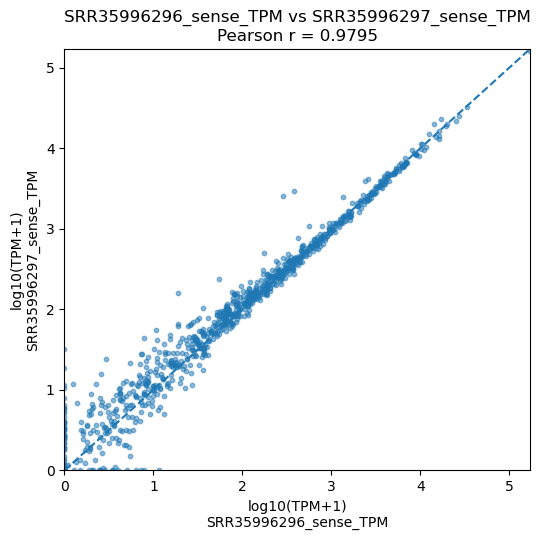

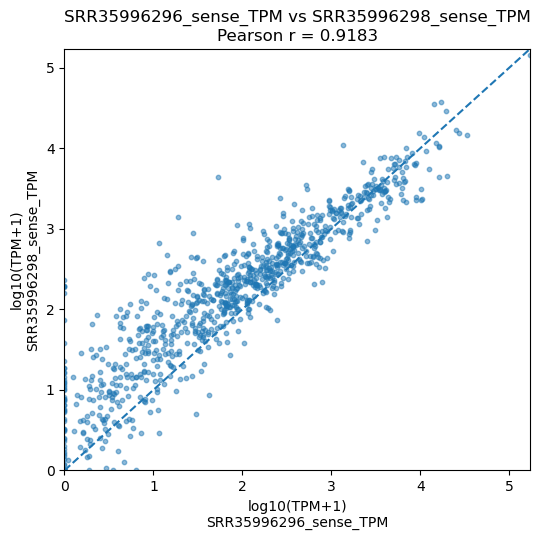

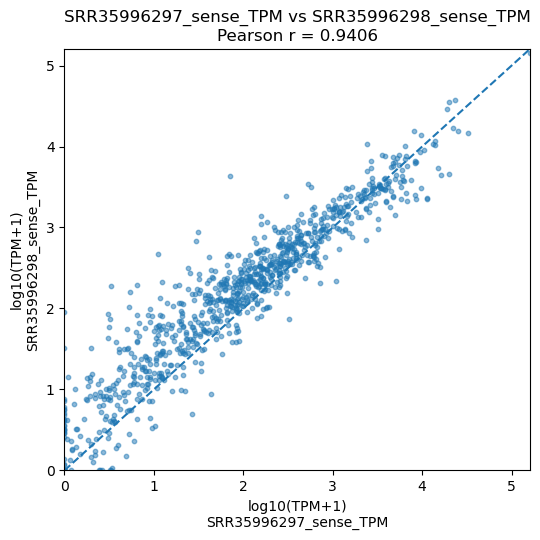

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

tpm_cols = [f"{sample}_sense_TPM" for sample in SAMPLES]

for a, b in combinations(tpm_cols, 2):
    x = np.log10(genes[a].astype(float) + 1.0)
    y = np.log10(genes[b].astype(float) + 1.0)

    r = np.corrcoef(x, y)[0, 1]

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(x, y, s=10, alpha=0.5)
    lims = [
        min(x.min(), y.min()),
        max(x.max(), y.max())
    ]
    plt.plot(lims, lims, linestyle="--")
    plt.xlim(lims)
    plt.ylim(lims)
    plt.xlabel(f"log10(TPM+1)\n{a}")
    plt.ylabel(f"log10(TPM+1)\n{b}")
    plt.title(f"{a} vs {b}\nPearson r = {r:.4f}")
    plt.tight_layout()
    plt.show()

### Merge into one Illumina Profile

In [6]:
SAMPLE_TO_BIO = {
    "SRR35996296": "sample_95",
    "SRR35996297": "sample_95",
    "SRR35996298": "sample_enr",
}

OUTPUT_TSV = Path(
    "/data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/Gene_Transcritpomics_Proteomics/illumina_TPM_profiles.tsv"
)

 #---------------------------------------------------------------------------
# Two-step averaging: tech reps within bio sample first, then bio samples
# ---------------------------------------------------------------------------
# Step 1: average technical replicates within each biological sample
bio_groups = {}
for sample in SAMPLES:
    bio = SAMPLE_TO_BIO[sample]
    bio_groups.setdefault(bio, []).append(sample)
 
for bio, reps in bio_groups.items():
    for strand_type in ["sense", "antisense"]:
        cols = [f"{s}_{strand_type}_TPM" for s in reps]
        genes[f"{bio}_{strand_type}_TPM"] = genes[cols].mean(axis=1)
 
# Step 2: average across biological samples (equal weight to sample1 and sample3)
bio_samples = sorted(bio_groups.keys())
for strand_type in ["sense", "antisense"]:
    bio_cols = [f"{bio}_{strand_type}_TPM" for bio in bio_samples]
    genes[f"avg_{strand_type}_TPM"] = genes[bio_cols].mean(axis=1)
 
# ---------------------------------------------------------------------------
# Export
# ---------------------------------------------------------------------------
export_cols = (
    ["locus_tag", "chrom", "start0", "end0", "strand", "gene_len"]
    # Per-sample TPM
    + [f"{s}_sense_TPM" for s in SAMPLES]
    + [f"{s}_antisense_TPM" for s in SAMPLES]
    # Per-biological-sample averaged TPM
    + [f"{bio}_sense_TPM" for bio in bio_samples]
    + [f"{bio}_antisense_TPM" for bio in bio_samples]
    # Final averaged TPM
    + ["avg_sense_TPM", "avg_antisense_TPM"]
)

genes[export_cols].to_csv(OUTPUT_TSV, sep="\t", index=False, float_format="%.4f")
print(f"Exported to {OUTPUT_TSV}")
print(f"  Genes: {len(genes)}")
print(f"  Columns: {len(export_cols)}")
print(genes[["locus_tag", "avg_sense_TPM", "avg_antisense_TPM"]].head(10))

Exported to /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/Gene_Transcritpomics_Proteomics/illumina_TPM_profiles.tsv
  Genes: 911
  Columns: 18
     locus_tag  avg_sense_TPM  avg_antisense_TPM
0  MMSYN1_0001     127.902027           0.791429
1  MMSYN1_0002      63.089631           0.591303
2  MMSYN1_0003      17.167420           0.000000
3  MMSYN1_0004       6.998972           2.239547
4  MMSYN1_0005     530.407861           0.406383
5  MMSYN1_0006     455.160877           4.593483
6  MMSYN1_0007     846.846645           3.464375
7  MMSYN1_0008     339.529155          14.738837
8  MMSYN1_0009      77.886781           5.019654
9  MMSYN1_0010     196.654508           5.935196


## Calculate TPM of PacBio



In [7]:
from pathlib import Path
import numpy as np
import pandas as pd

PACBIO_DEPTH_FOLDER = Path(
    "/data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/"
    "PacBio_Processing/depth_bedgraph/"
)
PACBIO_PREFIX = "syn1.PacBio.FLNC.HQ"

pacbio_genes = GENES.copy().reset_index(drop=True)
pacbio_genes["start0"] = pacbio_genes["start0"].astype(int)
pacbio_genes["end0"] = pacbio_genes["end0"].astype(int)
pacbio_genes["gene_len"] = pacbio_genes["end0"] - pacbio_genes["start0"]

plus_file  = PACBIO_DEPTH_FOLDER / f"{PACBIO_PREFIX}.plus.bedGraph"
minus_file = PACBIO_DEPTH_FOLDER / f"{PACBIO_PREFIX}.minus.bedGraph"

_, plus_prefix  = load_depth_array_from_bedgraph(plus_file)
_, minus_prefix = load_depth_array_from_bedgraph(minus_file)

sense_vals     = np.zeros(len(pacbio_genes), dtype=np.float64)
antisense_vals = np.zeros(len(pacbio_genes), dtype=np.float64)

for i, row in pacbio_genes.iterrows():
    chrom  = row["chrom"]
    start0 = int(row["start0"])
    end0   = int(row["end0"])
    glen   = int(row["gene_len"])
    strand = row["strand"]

    plus_mean  = (plus_prefix[chrom][end0]  - plus_prefix[chrom][start0])  / glen
    minus_mean = (minus_prefix[chrom][end0] - minus_prefix[chrom][start0]) / glen

    if strand == "+":
        sense_vals[i]     = plus_mean
        antisense_vals[i] = minus_mean
    else:
        sense_vals[i]     = minus_mean
        antisense_vals[i] = plus_mean

pacbio_genes["PacBio_sense_avg_depth"]     = sense_vals
pacbio_genes["PacBio_antisense_avg_depth"] = antisense_vals

# TPM: normalise by gene length (already done via avg depth) then scale to 1e6
denom = sense_vals.sum() + antisense_vals.sum()
if denom == 0:
    pacbio_genes["PacBio_sense_TPM"]     = 0.0
    pacbio_genes["PacBio_antisense_TPM"] = 0.0
else:
    pacbio_genes["PacBio_sense_TPM"]     = sense_vals     / denom * 1e6
    pacbio_genes["PacBio_antisense_TPM"] = antisense_vals / denom * 1e6

OUTPUT_PACBIO_TSV = Path(
    "/data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/"
    "Gene_Transcritpomics_Proteomics/pacbio_TPM_profiles.tsv"
)
export_cols = [
    "locus_tag", "chrom", "start0", "end0", "strand", "gene_len",
    "PacBio_sense_avg_depth", "PacBio_antisense_avg_depth",
    "PacBio_sense_TPM", "PacBio_antisense_TPM",
]
pacbio_genes[export_cols].to_csv(OUTPUT_PACBIO_TSV, sep="\t", index=False, float_format="%.4f")
print(f"Exported to {OUTPUT_PACBIO_TSV}")
print(f"  Genes: {len(pacbio_genes)}")
pacbio_genes[["locus_tag", "strand", "PacBio_sense_TPM", "PacBio_antisense_TPM"]].head(10)

Exported to /data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics/Gene_Transcritpomics_Proteomics/pacbio_TPM_profiles.tsv
  Genes: 911


,locus_tag,strand,PacBio_sense_TPM,PacBio_antisense_TPM
0,MMSYN1_0001,+,2653.153109,1.495869
1,MMSYN1_0002,+,404.456802,4.554560
2,MMSYN1_0003,+,28.921065,1.688443
3,MMSYN1_0004,+,17.826025,1.037132
4,MMSYN1_0005,+,84.723537,0.000000
5,MMSYN1_0006,+,575.825384,8.201664
6,MMSYN1_0007,+,598.749295,2.557494
7,MMSYN1_0008,-,94.741317,7.944933
8,MMSYN1_0009,-,511.418755,7.050863
9,MMSYN1_0010,-,352.860264,4.535778


In [8]:
pacbio_genes["PacBio_sense_TPM"].sum(), pacbio_genes["PacBio_antisense_TPM"].sum()

(np.float64(979496.9820787513), np.float64(20503.0179212487))

In [9]:
genes['PacBio_sense_TPM'] = pacbio_genes['PacBio_sense_TPM']
genes["PacBio_antisense_TPM"] = pacbio_genes["PacBio_antisense_TPM"]

In [15]:
genes.to_csv("./syn1_Illumina_PacBio_TPM_profiles.csv",index=False, float_format="%.4f")

## Correlate PacBio w. Illumina

- Relatively low correlation found:  
Pearson r = 0.6 for log10 between PacBio and Illumina.   
No significant read length biase observed.  
No significant read count biase found.



/home/enguang/anaconda3/envs/RNAseq/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/enguang/anaconda3/envs/RNAseq/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


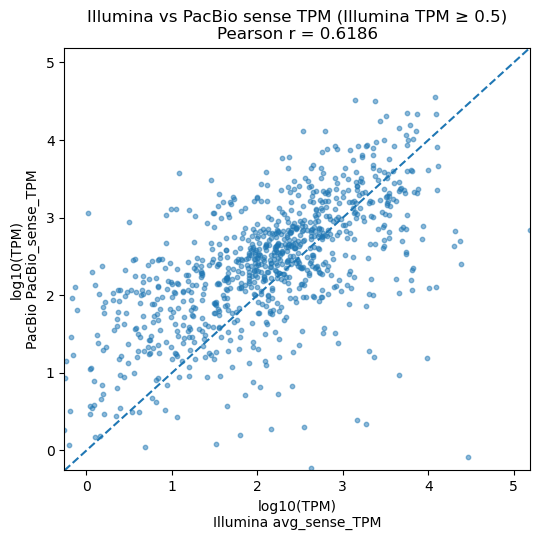

Genes passing threshold (Illumina TPM ≥ 0.5): 884
Pearson correlation of sense TPM:


,Illumina_avg_sense_TPM,PacBio_sense_TPM
Illumina_avg_sense_TPM,1.000000,0.127603
PacBio_sense_TPM,0.127603,1.000000


Pearson correlation of log10(TPM):


,Illumina_avg_sense_TPM,PacBio_sense_TPM
Illumina_avg_sense_TPM,1.000000,0.618603
PacBio_sense_TPM,0.618603,1.000000


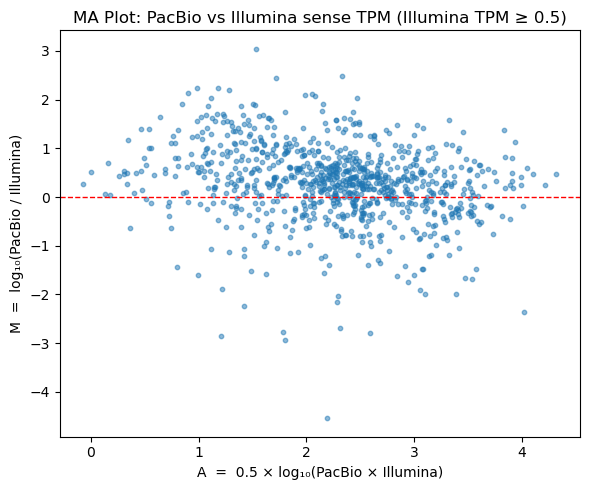

In [10]:
import numpy as np
import matplotlib.pyplot as plt

low_threshold = .5

# ── Scatter plot (log10 TPM) ────────────────────────────────────────────────
x_all = np.log10(genes["avg_sense_TPM"].astype(float))
y_all = np.log10(pacbio_genes["PacBio_sense_TPM"].astype(float))

mask = (x_all >= np.log10(low_threshold)) & (y_all >= np.log10(low_threshold))
x = x_all[mask]
y = y_all[mask]

r = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(5.5, 5.5))
plt.scatter(x, y, s=10, alpha=0.5)
lims = [min(x.min(), y.min()), max(x.max(), y.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("log10(TPM)\nIllumina avg_sense_TPM")
plt.ylabel("log10(TPM)\nPacBio PacBio_sense_TPM")
plt.title(f"Illumina vs PacBio sense TPM (Illumina TPM ≥ {low_threshold})\nPearson r = {r:.4f}")
plt.tight_layout()
plt.show()

# ── Pearson correlation tables ────────────────────────────────────────────────
corr_df = pd.DataFrame({
    "Illumina_avg_sense_TPM": genes["avg_sense_TPM"].values[mask],
    "PacBio_sense_TPM": pacbio_genes["PacBio_sense_TPM"].values[mask],
})
print(f"Genes passing threshold (Illumina TPM ≥ {low_threshold}): {mask.sum()}")
print("Pearson correlation of sense TPM:")
display(corr_df.corr(method="pearson"))

log_corr_df = np.log10(corr_df)
print("Pearson correlation of log10(TPM):")
display(log_corr_df.corr(method="pearson"))

# ── MA plot ───────────────────────────────────────────────────────────────────
illumina = genes["avg_sense_TPM"].astype(float).values[mask]
pacbio   = pacbio_genes["PacBio_sense_TPM"].astype(float).values[mask]

M = np.log10((pacbio) / (illumina))
A = 0.5 * np.log10((pacbio) * (illumina))

plt.figure(figsize=(6, 5))
plt.scatter(A, M, s=10, alpha=0.5)
plt.axhline(0, color="red", linewidth=1, linestyle="--")
plt.xlabel("A  =  0.5 × log₁₀(PacBio × Illumina)")
plt.ylabel("M  =  log₁₀(PacBio / Illumina)")
plt.title(f"MA Plot: PacBio vs Illumina sense TPM (Illumina TPM ≥ {low_threshold})")
plt.tight_layout()
plt.show()

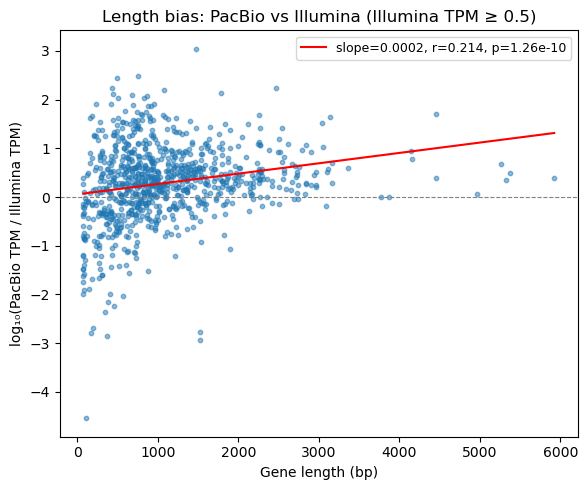

Linear regression: slope=0.00021, Pearson r=0.2141, p=1.26e-10
Negative slope would indicate Iso-Seq length bias (shorter genes enriched in PacBio).


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Apply same threshold mask
illumina_tpm = genes["avg_sense_TPM"].astype(float).values
pacbio_tpm   = pacbio_genes["PacBio_sense_TPM"].astype(float).values
gene_len     = genes["gene_len"].astype(float).values

mask = (illumina_tpm >= low_threshold) & (pacbio_tpm >= low_threshold)

illumina_m = illumina_tpm[mask]
pacbio_m   = pacbio_tpm[mask]
gene_len_m = gene_len[mask]

log10_ratio = np.log10((pacbio_m) / (illumina_m))

# Linear regression
slope, intercept, r, p, _ = stats.linregress(gene_len_m, log10_ratio)

x_line = np.array([gene_len_m.min(), gene_len_m.max()])
y_line = slope * x_line + intercept

plt.figure(figsize=(6, 5))
plt.scatter(gene_len_m, log10_ratio, s=10, alpha=0.5)
plt.plot(x_line, y_line, color="red", linewidth=1.5,
         label=f"slope={slope:.4f}, r={r:.3f}, p={p:.2e}")
plt.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.xlabel("Gene length (bp)")
plt.ylabel("log₁₀(PacBio TPM / Illumina TPM)")
plt.title(f"Length bias: PacBio vs Illumina (Illumina TPM ≥ {low_threshold})")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Linear regression: slope={slope:.5f}, Pearson r={r:.4f}, p={p:.2e}")
print("Negative slope would indicate Iso-Seq length bias (shorter genes enriched in PacBio).")

<!-- ## Draw Sequencing Depth -->


Borrow the following function from Troy Brier

One significant observation is that nearly all genes have anti-sense transcription.

In [ ]:
# import os

# HOME_DIR = "/data/enguang/Transcriptomics/Minimal_Cells_Transcriptomics_Proteomics"
# WORK_DIR = os.path.join(HOME_DIR, "Gene_Transcriptomics_Proteomics")

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from matplotlib.collections import LineCollection

# df = pd.read_csv(
#     "syn1.PacBio.FLNC.mapped_read_length_counts.tsv",
#     sep="\t"
# )

# x = df["aligned_length"].to_numpy()
# y = df["count"].to_numpy()
# mask = x > 0
# x, y = x[mask], y[mask]

# segs = np.stack([np.column_stack([x, np.zeros_like(y)]),
#                  np.column_stack([x, y])], axis=1)

# fig, ax = plt.subplots(figsize=(6,4))
# ax.add_collection(LineCollection(segs, colors='C0', linewidths=1.0))
# ax.set_xscale('log')
# ax.set_xlim(x.min()*0.9, x.max()*1.1)
# ax.set_ylim(0, 1.2*int(y.max()))
# ax.set_xlabel("Aligned read length (nt, log scale)")
# ax.set_ylabel("Number of reads")
# ax.set_title("Distribution of mapped FLNC read lengths")
# plt.tight_layout(); plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'syn1.PacBio.FLNC.mapped_read_length_counts.tsv'

In [ ]:
# ### Sequencing depth

# import pandas as pd
# import matplotlib.pyplot as plt

# prefix = "syn1.PacBio.FLNC"
# depth_tsv = f"{prefix}.depth_per_base.tsv"

# # depth_per_base.tsv: contig, pos(1-based), depth
# df_depth = pd.read_csv(depth_tsv, sep="\t", header=None, names=["contig","pos","depth"])

# # Calculate the number of base pairs that are never mapped (depth == 0)
# never_mapped_bp = (df_depth["depth"] == 0).sum()
# print(f"Number of base pairs never mapped (depth == 0): {never_mapped_bp}")
# print(f"The percentage of the genome that is never mapped: {never_mapped_bp / df_depth['depth'].sum():.2e}")

# df_depth["depth"].describe()


In [ ]:
# max_depth_idx = df_depth["depth"].idxmax()
# max_depth_pos = df_depth.loc[max_depth_idx, "pos"]
# print(f"Position of max depth: {max_depth_pos}")

In [ ]:
# plt.figure(figsize=(7,4))
# plt.hist(df_depth["depth"], bins=100, color='C2', edgecolor='black', log=False, 
# # range=(0, 100)
# )
# plt.xlabel("Per-base sequencing depth")
# plt.ylabel("Number of bases (log scale)")
# plt.title("Distribution of per-base sequencing depth")
# plt.tight_layout()
# plt.show()

In [ ]:
# bin_size = 100

# # integer bin index (0-based), then average depth per bin
# df_depth["bin"] = (df_depth["pos"] - 1) // bin_size
# df_bin = df_depth.groupby(["contig","bin"], as_index=False)["depth"].mean()
# df_bin["pos_mid"] = df_bin["bin"] * bin_size + (bin_size//2) + 1

# plt.figure(figsize=(10,3))
# plt.plot(df_bin["pos_mid"], df_bin["depth"], linewidth=0.8)
# plt.xlabel(f"Genomic position (bp; {bin_size}-bp bins)")
# plt.ylabel("Mean depth (log10 scale)")
# plt.yscale("log")
# plt.title("Binned transcriptome depth across the genome")
# plt.tight_layout()
# plt.show()


In [ ]:
# prefix = "syn1.PacBio.FLNC"

# depth_tsv = f"{prefix}.depth_forward.tsv"
# df_forward_depth = pd.read_csv(depth_tsv, sep="\t", header=None, names=["contig","pos","depth"])

# depth_tsv = f"{prefix}.depth_reverse.tsv"
# df_reverse_depth = pd.read_csv(depth_tsv, sep="\t", header=None, names=["contig","pos","depth"])

# bin_size = 100

# # integer bin index (0-based), then average depth per bin
# df_forward_depth["bin"] = (df_forward_depth["pos"] - 1) // bin_size
# df_forward_bin = df_forward_depth.groupby(["contig","bin"], as_index=False)["depth"].mean()
# df_forward_bin["pos_mid"] = df_forward_bin["bin"] * bin_size + (bin_size//2) + 1

# plt.figure(figsize=(10,3))
# plt.plot(df_forward_bin["pos_mid"], df_forward_bin["depth"], linewidth=0.8)
# plt.xlabel(f"Genomic position (bp; {bin_size}-bp bins)")
# plt.ylabel("Mean depth (log10 scale)")
# plt.yscale("log")
# plt.title("Binned transcriptome depth across the genome (forward strand)")
# plt.tight_layout()
# plt.show()

# # integer bin index (0-based), then average depth per bin
# df_reverse_depth["bin"] = (df_reverse_depth["pos"] - 1) // bin_size
# df_reverse_bin = df_reverse_depth.groupby(["contig","bin"], as_index=False)["depth"].mean()
# df_reverse_bin["pos_mid"] = df_reverse_bin["bin"] * bin_size + (bin_size//2) + 1

# plt.figure(figsize=(10,3))
# plt.plot(df_reverse_bin["pos_mid"], df_reverse_bin["depth"], linewidth=0.8)
# plt.xlabel(f"Genomic position (bp; {bin_size}-bp bins)")
# plt.ylabel("Mean depth (log10 scale)")
# plt.yscale("log")
# plt.title("Binned transcriptome depth across the genome (reverse strand)")
# plt.tight_layout()
# plt.show()

In [ ]:
import pandas as pd
import draw_whole_PDF as draw_pdf

cols=['Locus Tag',
      'Strand',
      'Start','End',
#       'Gene Length','In Syn3A',
      'RNA Type',
#       'SD Strength',
#       'P Strength',
      'P Seq',
      'P Dist',
      'P Functional',
      'Termination',
      'Term Start',
      'Term Length',
#       'Products'
     ]

syn1=pd.read_excel(HOME_DIR + '/Genomes_Input/Motif_Identifications.xlsx', sheet_name='JCVI-Syn1.0', header=0)
print(syn1.columns)
syn1['Gene Length']=syn1['End']-syn1['Start']

prefix = "syn1.PacBio.FLNC"
depth_tsv = f"{prefix}.depth_forward.tsv"
df_forward_depth = pd.read_csv(depth_tsv, sep="\t", header=None, names=["contig","pos","depth"])
depth_tsv = f"{prefix}.depth_reverse.tsv"
df_reverse_depth = pd.read_csv(depth_tsv, sep="\t", header=None, names=["contig","pos","depth"])

forward_depth = df_forward_depth["depth"].to_numpy()
backward_depth = df_reverse_depth["depth"].to_numpy()

draw_pdf.draw_whole_genome('syn1.0_PacBio_RNASeq_coverage_nonlog',
						6,
						10000,
						150,#dpi
						syn1[cols],
						[forward_depth, backward_depth],
						False,
						log_scale=False)